# Customer Churn Prediction

## Exploratory Data Analysis (EDA)

### Objective

Explore customer behavior, identify factors influencing churn, and derive business insights before building machine learning models.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Better plot appearance
plt.style.use("ggplot")

# Display all columns
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Dataset Shape:", df.shape)
print("\n")

print("Columns:")
print(df.columns)

Dataset Shape: (7032, 21)


Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

## 1. Target Variable Analysis

### Business Question

How many customers churned and how many stayed?

In [6]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [7]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


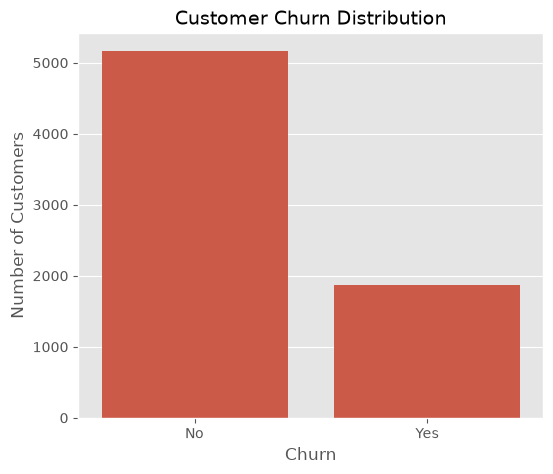

In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution", fontsize=14)

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

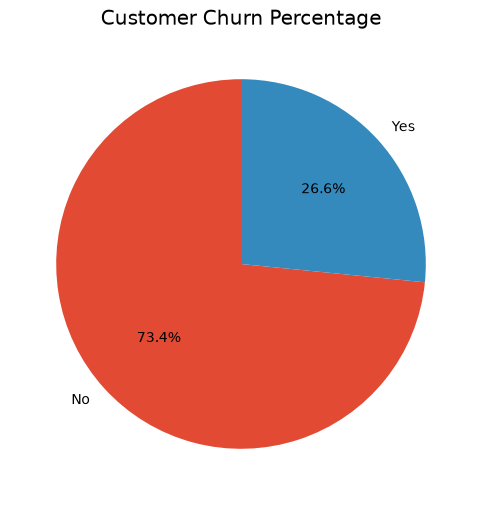

In [9]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Customer Churn Percentage")

plt.show()

### Observation

- Around **73%** of customers remained with the company.
- Around **27%** of customers churned.

### Business Insight

Although most customers remain, the churn rate is high enough to justify building a predictive model. Reducing churn even by a few percentage points could significantly improve revenue and customer lifetime value.

## 2. Gender Analysis

### Business Question

Does customer gender influence churn?

In [10]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

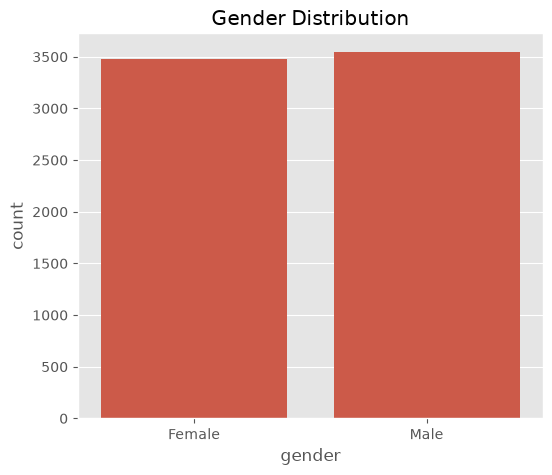

In [11]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

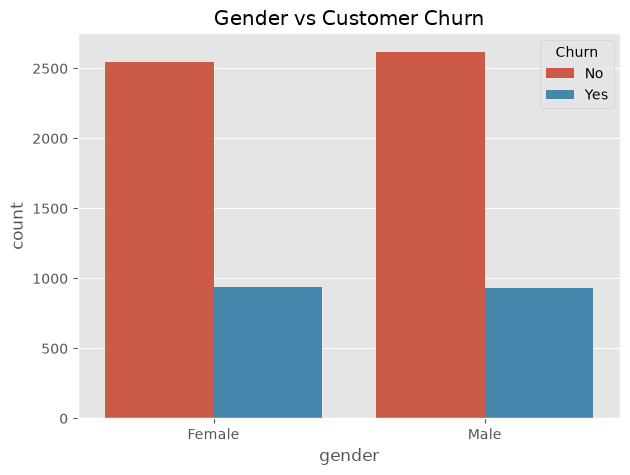

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="gender",
    hue="Churn"
)

plt.title("Gender vs Customer Churn")

plt.show()

In [13]:
gender_churn = (
    pd.crosstab(
        df["gender"],
        df["Churn"],
        normalize="index"
    ) * 100
)

gender_churn.round(2)

Churn,No,Yes
gender,,
Female,73.04,26.96
Male,73.80,26.20


### Observation
- Gender distribution is balanced.
- Churn is similar for both genders.

### Business Insight
Gender is not a major churn factor.

## 3. Senior Citizen Analysis

### Business Question

Does being a senior citizen influence customer churn?

In [14]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

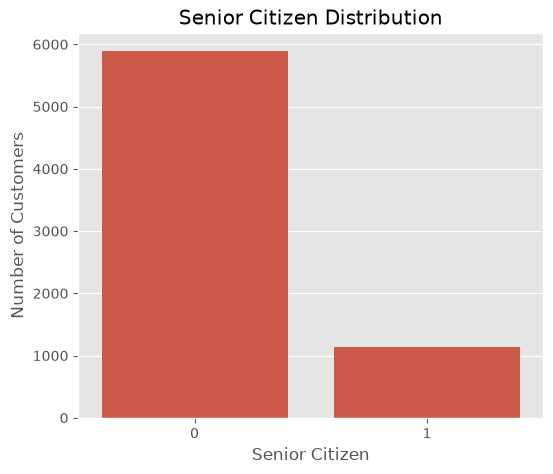

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="SeniorCitizen"
)

plt.title("Senior Citizen Distribution")

plt.xlabel("Senior Citizen")

plt.ylabel("Number of Customers")

plt.show()

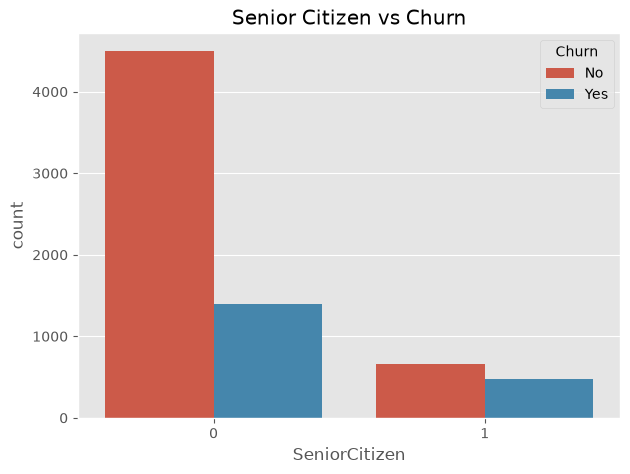

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")

plt.show()

In [17]:
senior_churn = (
    pd.crosstab(
        df["SeniorCitizen"],
        df["Churn"],
        normalize="index"
    ) * 100
)

senior_churn.round(2)

Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


### Observation
- Fewer senior customers.
- Seniors churn more.

### Business Insight
Provide better support for senior customers.

## 4. Partner Analysis

### Business Question

Does having a partner reduce customer churn?

In [18]:
df["Partner"].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

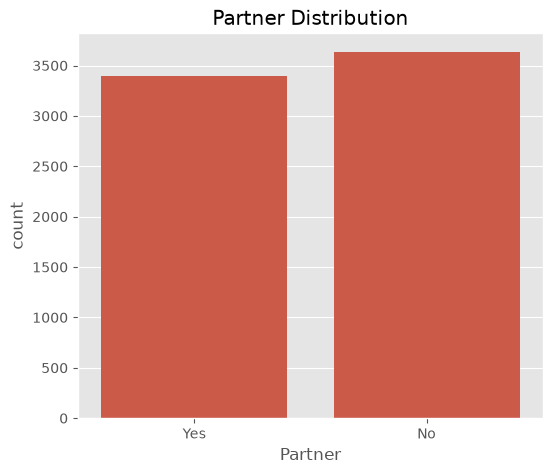

In [19]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Partner"
)

plt.title("Partner Distribution")

plt.show()

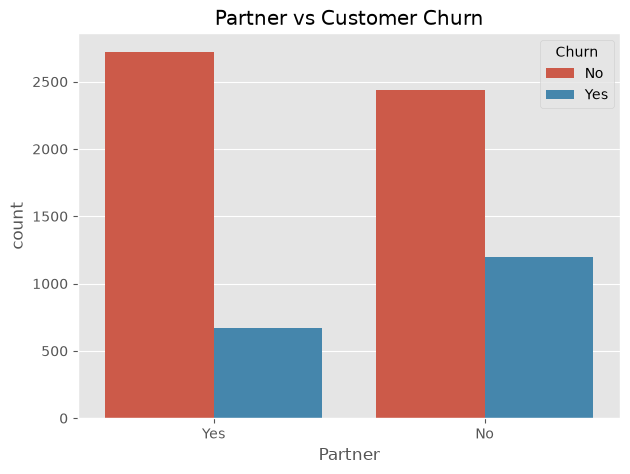

In [20]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

plt.title("Partner vs Customer Churn")

plt.show()

In [21]:
partner_churn = (
    pd.crosstab(
        df["Partner"],
        df["Churn"],
        normalize="index"
    ) * 100
)

partner_churn.round(2)

Churn,No,Yes
Partner,,
No,67.02,32.98
Yes,80.28,19.72


### Observation
- Customers without partners churn more.
- Partnered customers are more loyal.

### Business Insight
Target single customers with personalized offers.

## 5. Dependents Analysis

### Business Question

Does having dependents influence customer churn?

In [28]:
df["Dependents"].value_counts()

Dependents
No     4933
Yes    2099
Name: count, dtype: int64

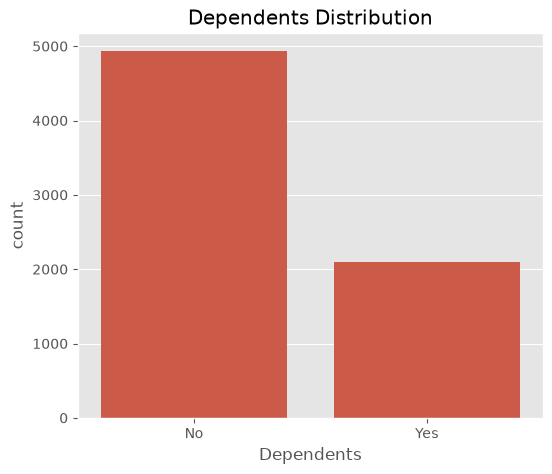

In [29]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Dependents"
)

plt.title("Dependents Distribution")

plt.show()

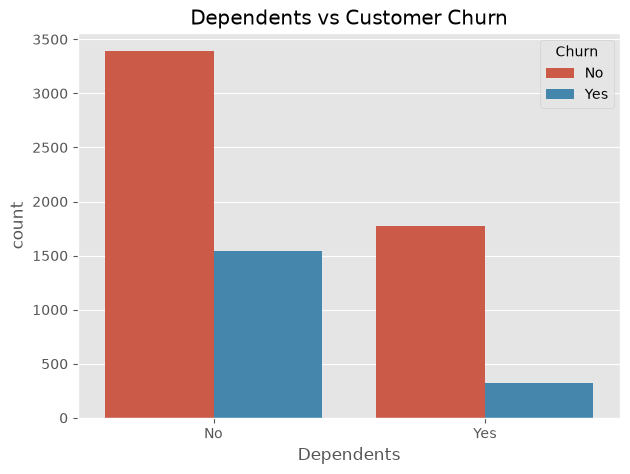

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

plt.title("Dependents vs Customer Churn")

plt.show()

In [31]:
dependents_churn = (
    pd.crosstab(
        df["Dependents"],
        df["Churn"],
        normalize="index"
    ) * 100
)

dependents_churn.round(2)

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.47,15.53


### Observation
- Customers with dependents churn less.
- Dependents indicate stronger customer loyalty.

### Business Insight
Promote family-oriented plans.

## 6. Contract Analysis

### Business Question

Does contract type affect customer churn?

In [32]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

### Observation
- Month-to-month is the most common contract.

### Business Insight
Most customers prefer flexible plans.

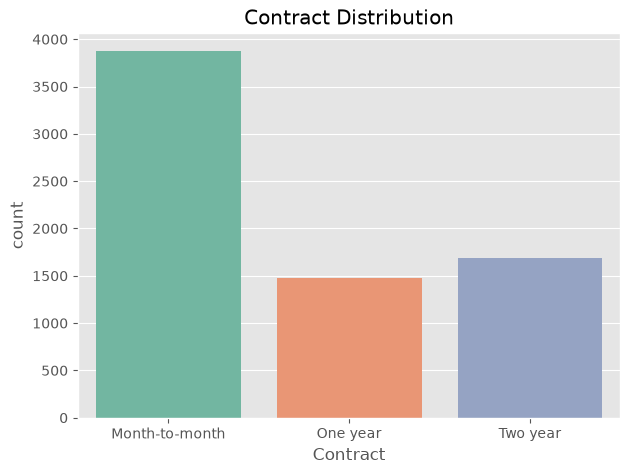

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Contract", palette="Set2")

plt.title("Contract Distribution")
plt.show()

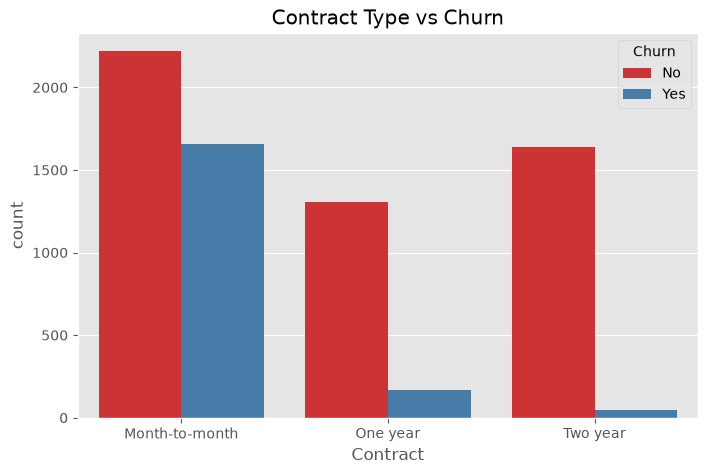

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn",
    palette="Set1"
)

plt.title("Contract Type vs Churn")
plt.show()

In [35]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


### Observation
- 55.1% customers use month-to-month contracts.
- Month-to-month customers show the highest churn (~43%).
- Two-year contracts have the lowest churn (~3%).

### Business Insight
Converting month-to-month customers to long-term contracts can significantly reduce churn.

## 7. Paperless Billing Analysis

### Business Question

Does paperless billing influence customer churn?

In [36]:
df["PaperlessBilling"].value_counts()

PaperlessBilling
Yes    4168
No     2864
Name: count, dtype: int64

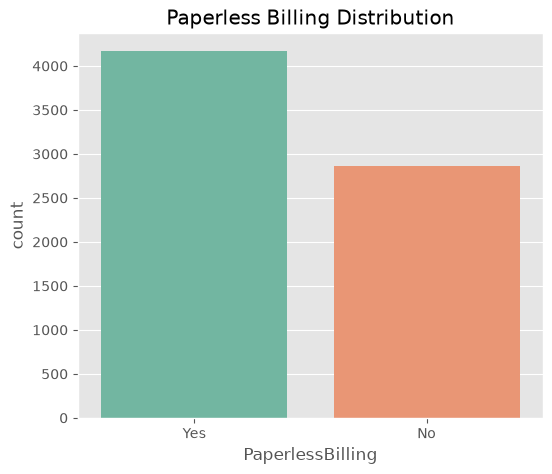

In [37]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="PaperlessBilling",
    palette="Set2"
)

plt.title("Paperless Billing Distribution")
plt.show()

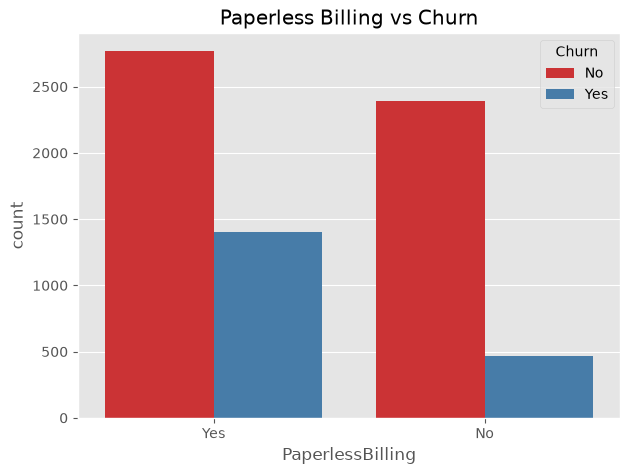

In [38]:

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="PaperlessBilling",
    hue="Churn",
    palette="Set1"
)

plt.title("Paperless Billing vs Churn")
plt.show()

In [39]:
paperless_churn = (
    pd.crosstab(
        df["PaperlessBilling"],
        df["Churn"],
        normalize="index"
    ) * 100
)

paperless_churn.round(2)

Churn,No,Yes
PaperlessBilling,,
No,83.62,16.38
Yes,66.41,33.59


### Observation
- ~59% customers use paperless billing.
- Churn is ~34% for paperless users.
- Churn is ~16% for non-paperless users.

### Business Insight
Review the digital billing experience and customer communication.

## 8. Payment Method Analysis

### Business Question

Which payment method has the highest customer churn?

In [40]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

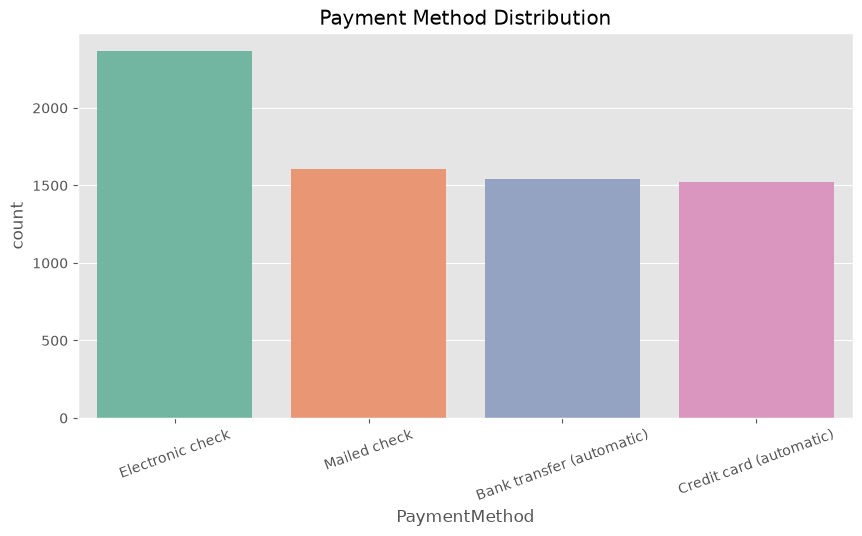

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    palette="Set2"
)

plt.xticks(rotation=20)
plt.title("Payment Method Distribution")

plt.show()

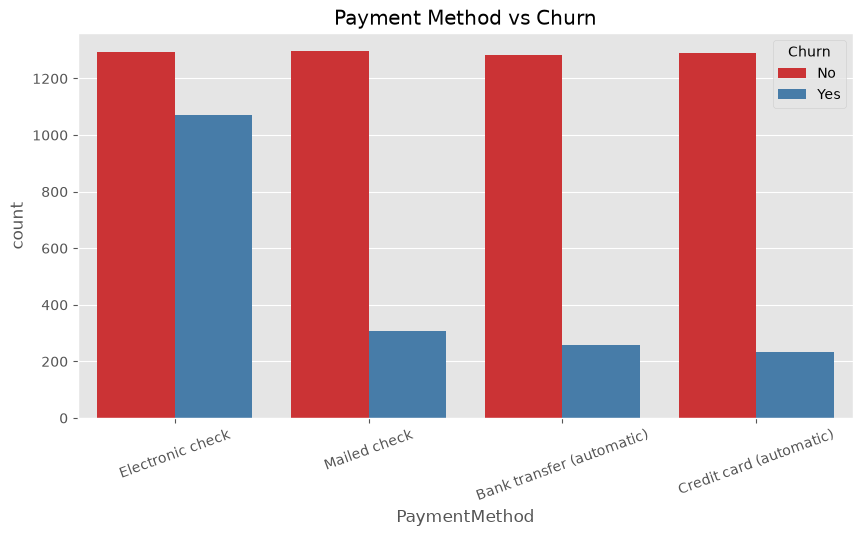

In [42]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn",
    palette="Set1"
)

plt.xticks(rotation=20)
plt.title("Payment Method vs Churn")

plt.show()

In [43]:
payment_churn = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100
)

payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


### Observation
- Electronic check has the highest churn (~45%).
- Automatic payment methods have the lowest churn (~15–17%).
- Auto-payment customers are more loyal.

### Business Insight
Encourage customers to switch to automatic payment methods.

## 9. Tenure Analysis

### Business Question
Does customer tenure affect churn?

In [44]:

df["tenure"].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

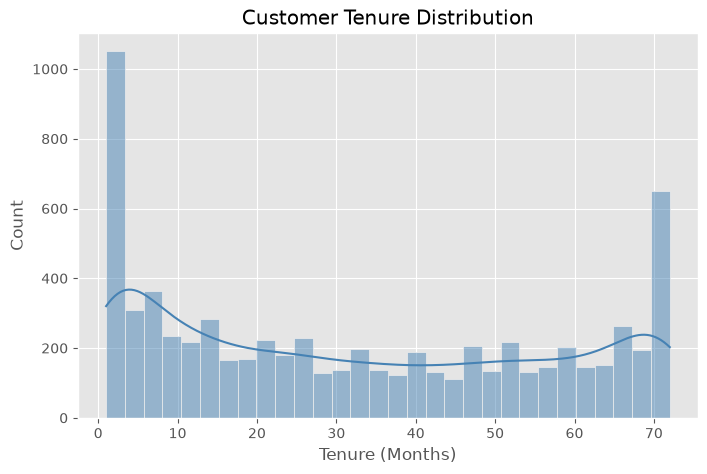

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.show()

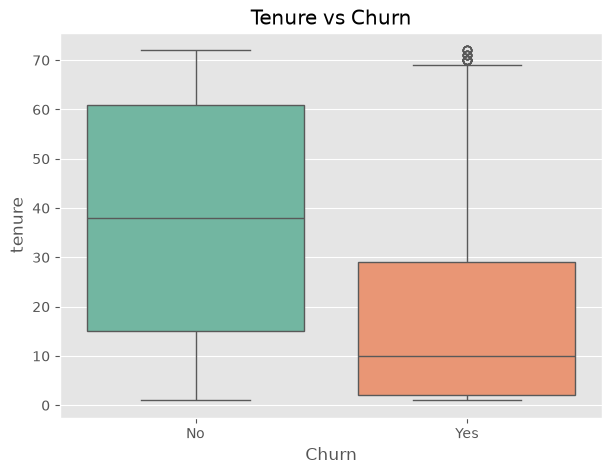

In [46]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="Set2"
)

plt.title("Tenure vs Churn")
plt.show()

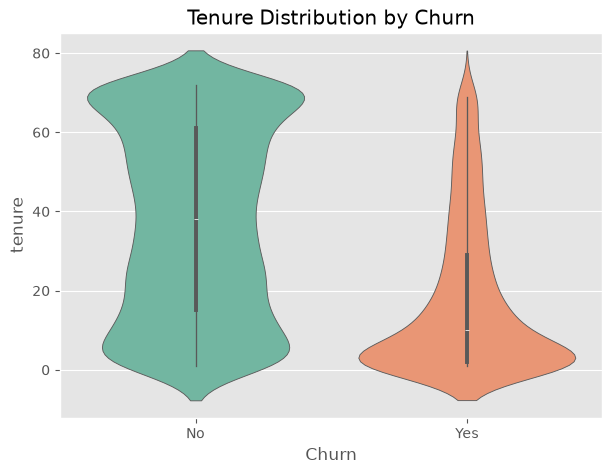

In [47]:
plt.figure(figsize=(7,5))

sns.violinplot(
    data=df,
    x="Churn",
    y="tenure",
    palette="Set2"
)

plt.title("Tenure Distribution by Churn")

plt.show()

### Observation
- Avg. tenure ≈ 32 months.
- Churn is highest among low-tenure customers.
- Long-tenure customers show higher retention.

### Business Insight
Prioritize retention during the first year of customer onboarding.

## 10. Internet Service Analysis

### Business Question

Does internet service type influence customer churn?

In [48]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

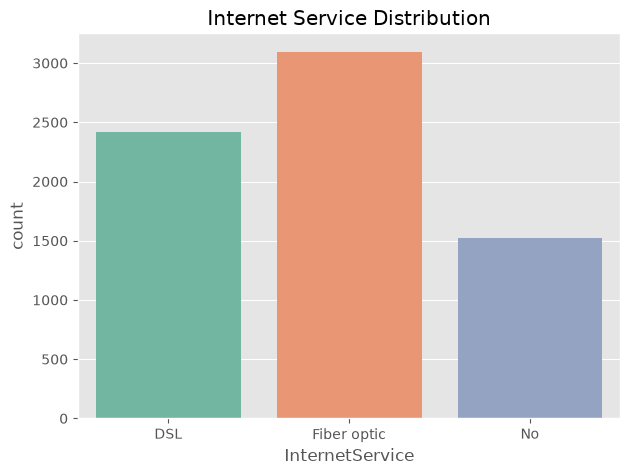

In [49]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="InternetService",
    palette="Set2"
)

plt.title("Internet Service Distribution")
plt.show()

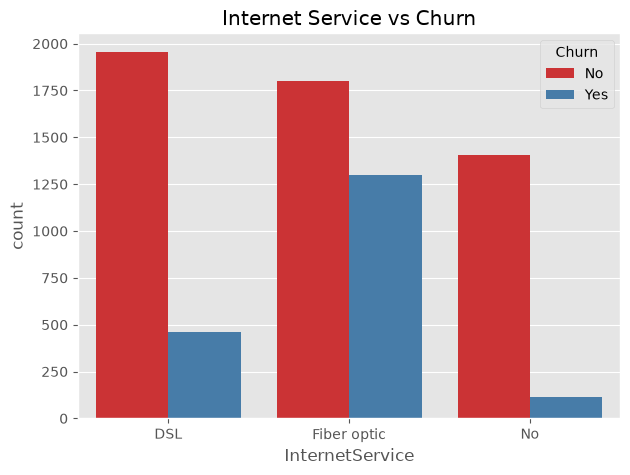

In [50]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn",
    palette="Set1"
)

plt.title("Internet Service vs Churn")
plt.show()

In [51]:
internet_churn = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
)

internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


### Observation
- Fiber optic customers have the highest churn (~42%).
- Customers without internet have the lowest churn (~7%).
- DSL customers are more likely to stay.

### Business Insight
Review pricing, reliability, and support for fiber optic services.

## 11. Online Security Analysis

### Business Question

Does online security affect customer churn?

In [52]:

df["OnlineSecurity"].value_counts()

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

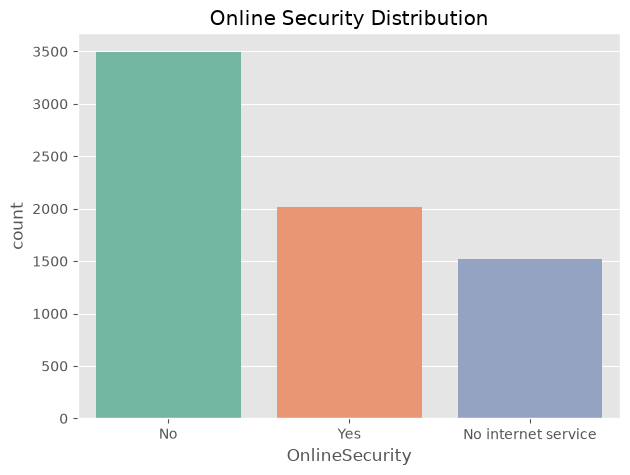

In [53]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    palette="Set2"
)

plt.title("Online Security Distribution")
plt.show()

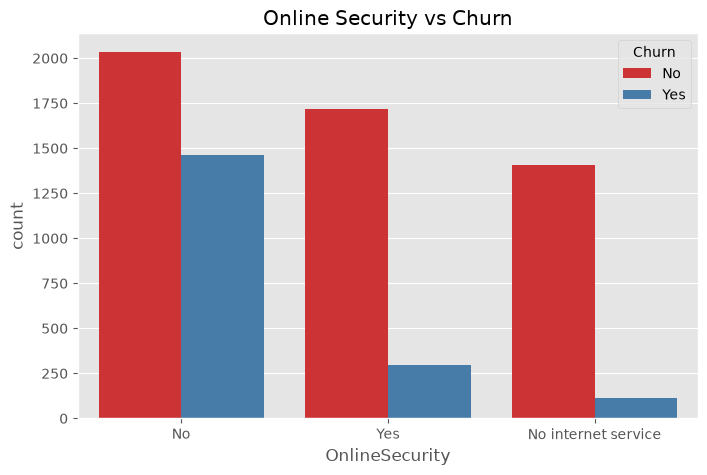

In [54]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn",
    palette="Set1"
)

plt.title("Online Security vs Churn")
plt.show()

In [55]:
security_churn = (
    pd.crosstab(
        df["OnlineSecurity"],
        df["Churn"],
        normalize="index"
    ) * 100
)

security_churn.round(2)

Churn,No,Yes
OnlineSecurity,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


### Observation
- Customers without online security show the highest churn (~42%).
- Security subscribers have much lower churn (~15%).

### Business Insight
Bundle or promote online security to improve customer retention.

## 12. Online Backup Analysis

### Business Question

Does online backup influence customer churn?

In [56]:

df["OnlineBackup"].value_counts()

OnlineBackup
No                     3087
Yes                    2425
No internet service    1520
Name: count, dtype: int64

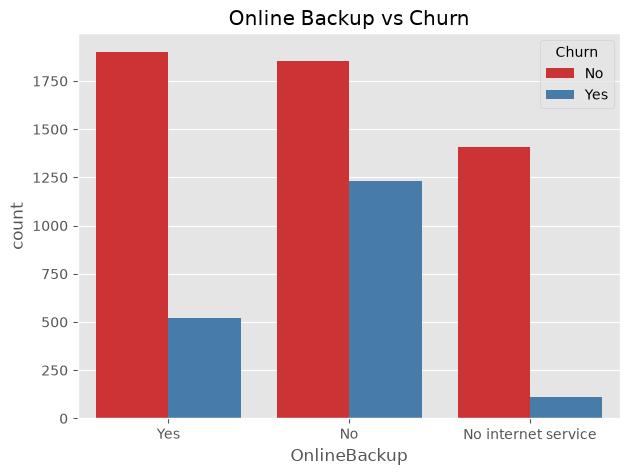

In [57]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="OnlineBackup", hue="Churn", palette="Set1")
plt.title("Online Backup vs Churn")
plt.show()

In [58]:
backup_churn = pd.crosstab(
    df["OnlineBackup"],
    df["Churn"],
    normalize="index"
) * 100

backup_churn.round(2)

Churn,No,Yes
OnlineBackup,,
No,60.06,39.94
No internet service,92.57,7.43
Yes,78.43,21.57


### Observation
- Customers without backup churn more.
- Backup users have higher retention.

### Business Insight
Bundle online backup with internet plans.

## 13. Device Protection Analysis

### Business Question


Does device protection reduce churn?

In [60]:
df["DeviceProtection"].value_counts()

DeviceProtection
No                     3094
Yes                    2418
No internet service    1520
Name: count, dtype: int64

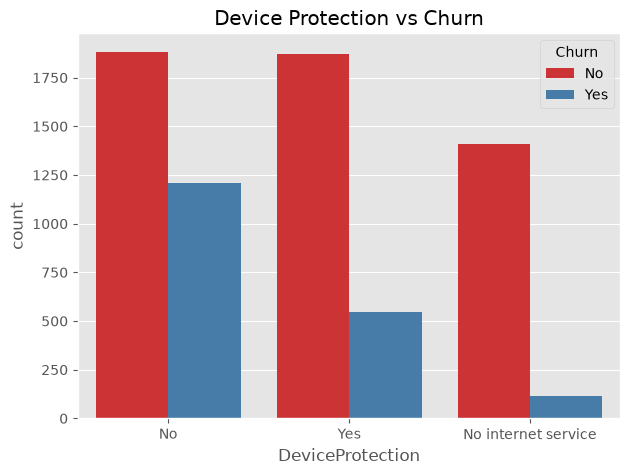

In [61]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="DeviceProtection", hue="Churn", palette="Set1")
plt.title("Device Protection vs Churn")
plt.show()

In [62]:
device_churn = pd.crosstab(
    df["DeviceProtection"],
    df["Churn"],
    normalize="index"
) * 100

device_churn.round(2)

Churn,No,Yes
DeviceProtection,,
No,60.86,39.14
No internet service,92.57,7.43
Yes,77.46,22.54


### Observation
- Protection users churn less.
- Non-users have higher churn.

### Business Insight
Promote device protection services.

## 14. Tech Support Analysis

### Business Question

Does tech support improve retention?

In [63]:
df["TechSupport"].value_counts()

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

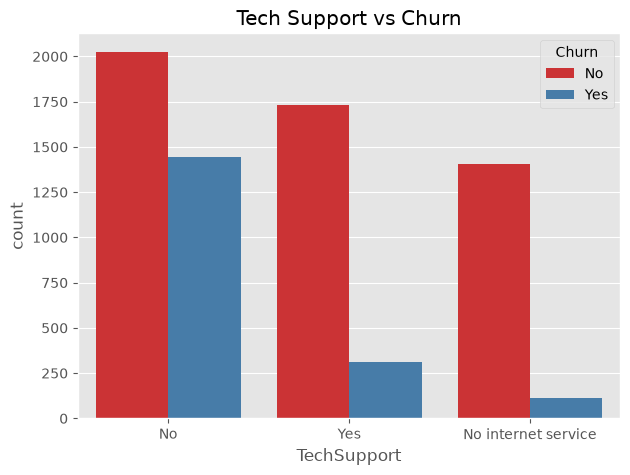

In [64]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="TechSupport", hue="Churn", palette="Set1")
plt.title("Tech Support vs Churn")
plt.show()

In [65]:
tech_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
) * 100

tech_churn.round(2)

Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


### Observation
- Customers without tech support churn the most.
- Tech support users have better retention.

### Business Insight
Strengthen customer support and service quality.

## 15. Streaming TV Analysis

### Business Question

Does streaming TV affect churn?

In [67]:
df["StreamingTV"].value_counts()

StreamingTV
No                     2809
Yes                    2703
No internet service    1520
Name: count, dtype: int64

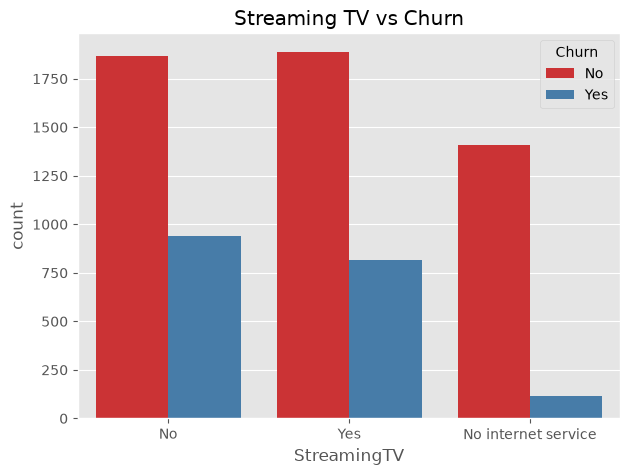

In [68]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="StreamingTV", hue="Churn", palette="Set1")
plt.title("Streaming TV vs Churn")
plt.show()

In [69]:
stream_tv = pd.crosstab(
    df["StreamingTV"],
    df["Churn"],
    normalize="index"
) * 100

stream_tv.round(2)

Churn,No,Yes
StreamingTV,,
No,66.46,33.54
No internet service,92.57,7.43
Yes,69.89,30.11


### Observation
- Streaming TV has a weak impact on churn.

### Business Insight
Streaming TV is not a major churn driver.

## 16. Streaming Movies Analysis

### Business Question

Does streaming movies affect churn?

In [70]:
df["StreamingMovies"].value_counts()

StreamingMovies
No                     2781
Yes                    2731
No internet service    1520
Name: count, dtype: int64

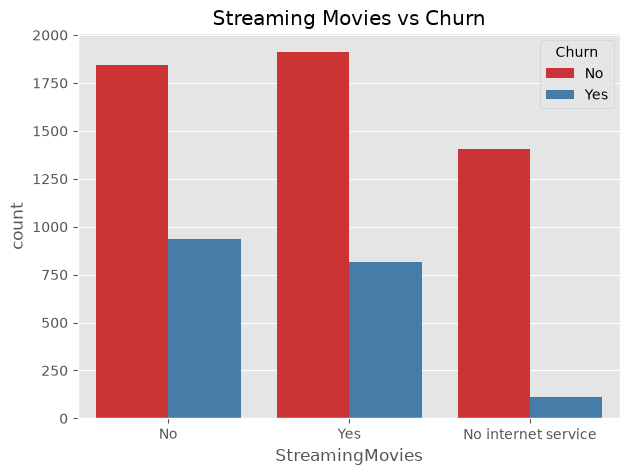

In [71]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x="StreamingMovies", hue="Churn", palette="Set1")
plt.title("Streaming Movies vs Churn")
plt.show()

In [72]:
movie_churn = pd.crosstab(
    df["StreamingMovies"],
    df["Churn"],
    normalize="index"
) * 100

movie_churn.round(2)

Churn,No,Yes
StreamingMovies,,
No,66.27,33.73
No internet service,92.57,7.43
Yes,70.05,29.95


### Observation
- Streaming movies show limited impact on churn.

### Business Insight

Content services alone are not enough to improve retention.

## 17. Monthly Charges Analysis

### Business Question

Do higher monthly charges increase customer churn?

In [73]:
df["MonthlyCharges"].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

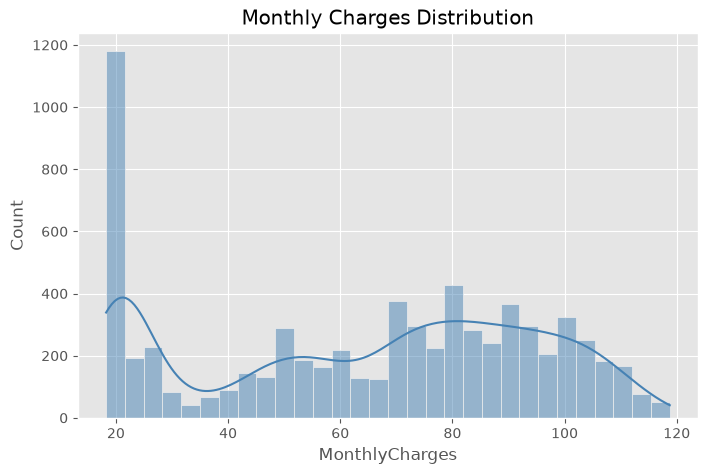

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Monthly Charges Distribution")
plt.show()

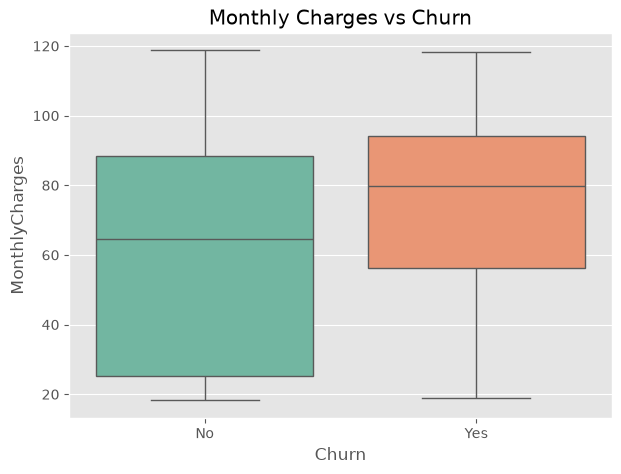

In [75]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Set2"
)

plt.title("Monthly Charges vs Churn")

plt.show()

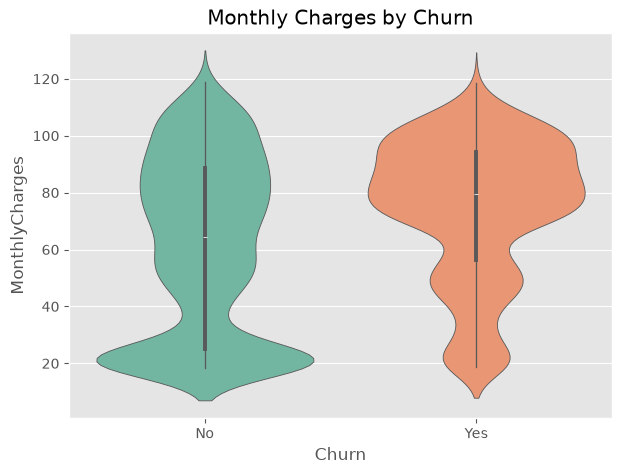

In [76]:
plt.figure(figsize=(7,5))

sns.violinplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    palette="Set2"
)

plt.title("Monthly Charges by Churn")
plt.show()

### Observation
- Avg. monthly charge ≈ $64.
- Churned customers have higher monthly charges.
- Higher pricing is associated with increased churn.

### Business Insight
Offer personalized discounts to high-billing customers.

## 18. Total Charges Analysis

### Business Question

Do total charges influence customer churn?

In [77]:

df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

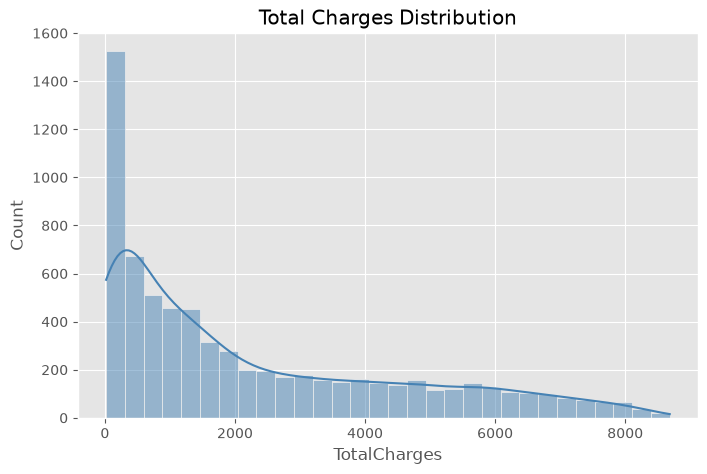

In [78]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="TotalCharges",
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Total Charges Distribution")
plt.show()

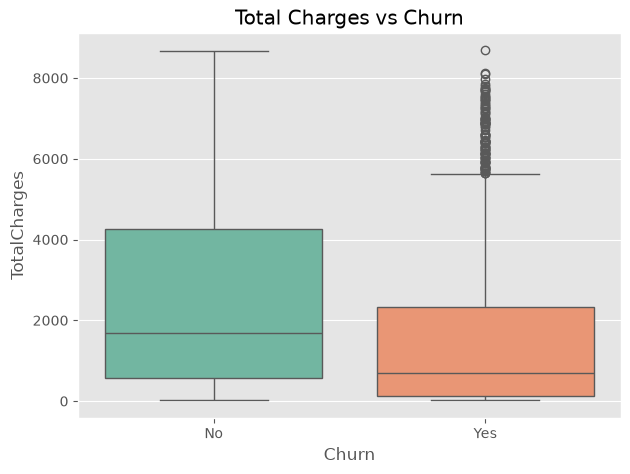

In [79]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges",
    palette="Set2"
)

plt.title("Total Charges vs Churn")
plt.show()

### Observation
- Retained customers have higher total charges.
- Low total charges are linked with higher churn.

### Business Insight
Reward long-term customers with loyalty programs.

## 19. Correlation Analysis

### Business Question

How are numerical features related?

In [80]:
numerical_df = df.select_dtypes(include=["int64", "float64"])

numerical_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [81]:
corr = numerical_df.corr()
corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


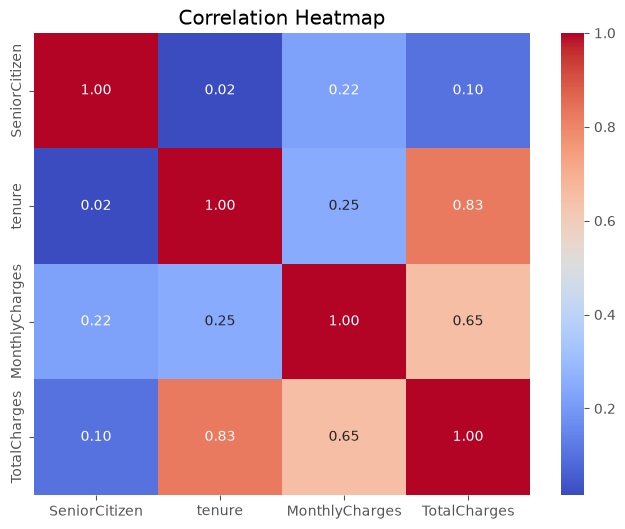

In [82]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation
- Tenure and Total Charges show the strongest positive correlation.
- Monthly Charges have a weaker relationship with tenure.

### Business Insight
Long-term customers contribute higher lifetime revenue.

# Key Business Insights

1. Churn rate is ~27%.
2. Month-to-month contracts have the highest churn.
3. Senior citizens churn more than non-seniors.
4. Customers with short tenure are more likely to churn.
5. Fiber optic users show higher churn than DSL users.
6. Customers without Online Security or Tech Support churn more.
7. Higher monthly charges are associated with increased churn.
8. Long-term customers generate higher lifetime value and show lower churn.

## Business Recommendations

- Promote annual and two-year contracts.
- Improve fiber optic service quality.
- Bundle Online Security and Tech Support.
- Retain new customers during their first year.
- Offer discounts to high-risk, high-billing customers.